In [1]:
import sys
sys.path.append('..')

In [2]:
from minbpe import RegexTokenizer

tokenizer = RegexTokenizer()
#tokenizer_path = "../output/tokenizer/darija_tokenizer.model"
#tokenizer_path = "../output/tokenizer/pedro_tokenizer.model"
tokenizer_path = "../output/tokenizer/pedro_nuevo_tokenizer2.model"
tokenizer.load(model_file=tokenizer_path)


def get_vocab_size(tokenizer: RegexTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

In [3]:
tokenizer.vocab

{0: b'\x00',
 1: b'\x01',
 2: b'\x02',
 3: b'\x03',
 4: b'\x04',
 5: b'\x05',
 6: b'\x06',
 7: b'\x07',
 8: b'\x08',
 9: b'\t',
 10: b'\n',
 11: b'\x0b',
 12: b'\x0c',
 13: b'\r',
 14: b'\x0e',
 15: b'\x0f',
 16: b'\x10',
 17: b'\x11',
 18: b'\x12',
 19: b'\x13',
 20: b'\x14',
 21: b'\x15',
 22: b'\x16',
 23: b'\x17',
 24: b'\x18',
 25: b'\x19',
 26: b'\x1a',
 27: b'\x1b',
 28: b'\x1c',
 29: b'\x1d',
 30: b'\x1e',
 31: b'\x1f',
 32: b' ',
 33: b'!',
 34: b'"',
 35: b'#',
 36: b'$',
 37: b'%',
 38: b'&',
 39: b"'",
 40: b'(',
 41: b')',
 42: b'*',
 43: b'+',
 44: b',',
 45: b'-',
 46: b'.',
 47: b'/',
 48: b'0',
 49: b'1',
 50: b'2',
 51: b'3',
 52: b'4',
 53: b'5',
 54: b'6',
 55: b'7',
 56: b'8',
 57: b'9',
 58: b':',
 59: b';',
 60: b'<',
 61: b'=',
 62: b'>',
 63: b'?',
 64: b'@',
 65: b'A',
 66: b'B',
 67: b'C',
 68: b'D',
 69: b'E',
 70: b'F',
 71: b'G',
 72: b'H',
 73: b'I',
 74: b'J',
 75: b'K',
 76: b'L',
 77: b'M',
 78: b'N',
 79: b'O',
 80: b'P',
 81: b'Q',
 82: b'R',
 83: b'

## Create the model

In [4]:
import torch
torch.manual_seed(3647)
#torch.cuda.set_per_process_memory_fraction(0.6,device=0)
#import os
#os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
#
#print(os.getenv("PYTORCH_CUDA_ALLOC_CONF"))

In [5]:
from transformer.pedro_model import GPTLanguageModel
from transformer import BASE_CONFIG, selConfig

#selConfig('pedro-small (124M)')
selConfig('pedro-medium (124M)')
#selConfig('gpt2-medium (355M)')

block_size = BASE_CONFIG['context_length']
n_embd = BASE_CONFIG['emb_dim']
n_head = BASE_CONFIG['n_heads']
n_layer = BASE_CONFIG['n_layers']
dropout = BASE_CONFIG['dropout']
#batch_size = min(32, torch.cuda.get_device_properties(0).total_memory // (1024**3))  # Ajuste dinámico
batch_size = 1
print(f'Batch Size: {batch_size}')
vocab_size = get_vocab_size(tokenizer)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)

#if hasattr(torch, 'compile'):
#    model_compiled = torch.compile(model, mode='max-autotune')
#else:
#    model_compiled = model
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

Batch Size: 1
155.929646 M parameters


In [6]:
print(model)
#print(model_compiled)

GPTLanguageModel(
  (token_embedding_table): Embedding(36398, 768)
  (position_embedding_table): Embedding(1024, 768)
  (blocks): Sequential(
    (0): Block(
      (self_attention): MultiHeadAttention(
        (heads): ModuleList(
          (0-11): 12 x Head(
            (key): Linear(in_features=768, out_features=64, bias=False)
            (query): Linear(in_features=768, out_features=64, bias=False)
            (value): Linear(in_features=768, out_features=64, bias=False)
            (dropout): Dropout(p=0.2, inplace=False)
          )
        )
        (projection): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (feed_forward): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (layer_norm_1): LayerN

## Load the data

In [6]:
import numpy as np

data_path = "../output/encoded_data/encoded_atlaset_p_nuevo.npy"
data = np.load(data_path, mmap_mode='r')
print('Data shape:', data.shape)

Data shape: (342662,)


In [7]:
split_index = int(0.9*len(data))
split_index

308395

## Helper functions

In [8]:
from torch.utils.data import Dataset, DataLoader
class GPTDataset(Dataset):
    def __init__(self, data, block_size, split='train', train_split=0.9):
        self.data = data
        self.block_size = block_size
        
        if split == 'train':
            self.start_idx = 0
            self.end_idx = int(train_split * len(data))
        else:
            self.start_idx = int(train_split * len(data))
            self.end_idx = len(data)
            
        self.length = self.end_idx - self.start_idx - block_size
    
    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        actual_idx = self.start_idx + idx
        x = torch.tensor(self.data[actual_idx:actual_idx + self.block_size], dtype=torch.long)
        y = torch.tensor(self.data[actual_idx + 1:actual_idx + self.block_size + 1], dtype=torch.long)
        return x, y

In [9]:
from typing import Tuple


def get_batch(split: str) -> Tuple[torch.Tensor, torch.Tensor]:
    # generate a small batch of data of inputs x and targets y
    if split == 'train':
        start_index = 0
        end_index = split_index
    else:
        start_index = split_index
        end_index = len(data)

    index = torch.randint(start_index, end_index - block_size, (batch_size,))
    x_batch, y_batch = [], []
    for i in index:
        x_batch.append(data[i:i+block_size])
        y_batch.append(data[i+1:i+block_size+1])

    x_batch = np.array(x_batch)
    y_batch = np.array(y_batch)

    x_batch = torch.tensor(x_batch, dtype=torch.long).to(device)
    y_batch = torch.tensor(y_batch, dtype=torch.long).to(device)

    return x_batch, y_batch

In [10]:
from typing import Dict


@torch.no_grad()
def estimate_loss(model, val_loader, max_eval_batches=100):
    model.eval()
    val_loss = 0
    num_batches = 0
    
    for batch_idx, (x_batch, y_batch) in enumerate(val_loader):
        if batch_idx >= max_eval_batches:
            break
            
        x_batch, y_batch = x_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
        
        with torch.amp.autocast(device_type=device):
            _, loss = model(x_batch, y_batch)
        
        val_loss += loss.item()
        num_batches += 1
    
    return {'val': val_loss / num_batches if num_batches > 0 else float('inf')}

In [11]:
def save_checkpoint(
    model: GPTLanguageModel,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str = "checkpoint.pth"
) -> None:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, file_path)

In [12]:
import math
learning_rate = 6e-4
max_lr = 6e-4
min_lr = max_lr * 0.1
warmup_steps = 715
max_steps = 19073 # 19,073 steps is ~1 epoch, if data is 10B tokens and batch size 0.5M tokens
def get_lr(it):
    # 1) linear warmup for warmup_iters steps
    if it < warmup_steps:
        return max_lr * (it+1) / warmup_steps
    # 2) if it > lr_decay_iters, return min learning rate
    if it > max_steps:
        return min_lr
    # 3) in between, use cosine decay down to min learning rate
    decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff starts at 1 and goes to 0
    return min_lr + coeff * (max_lr - min_lr)

## Training

In [13]:
torch.cuda.empty_cache()

In [15]:
from tqdm import tqdm

torch.set_float32_matmul_precision('high')

gradient_accumulation_steps = 8
eval_interval = 1000
save_interval = 10000
num_workers = 4  # Para carga asíncrona de datos
num_epochs=2
# Crear datasets optimizados
train_dataset = GPTDataset(data, block_size, split='train')
val_dataset = GPTDataset(data, block_size, split='val')

# equivalent to len(data) - block_size
total_data_to_process = split_index - block_size
total_data_to_process_in_batches = total_data_to_process // batch_size
train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,  # Acelera transferencias a GPU
        persistent_workers=True  # Mantiene workers activos
    )
    
val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=True
    )
#learning_rate = 3e-4
#optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
#optimizer = torch.optim.AdamW(
#        model.parameters(), 
#        lr=learning_rate,
#        betas=(0.9, 0.95),
#        weight_decay=1e-1,
#        eps=1e-8
#    )
optimizer=model.configure_optimizers(weight_decay=0.1, learning_rate=6e-4, device_type=device)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=len(train_loader), eta_min=1e-6)
batches_processed = 0
step=0
train_losses, val_losses = [], []
optimizer.zero_grad(set_to_none=True)

for epoch in range(num_epochs):  # Un epoch completo
    epoch_loss = 0
    num_batches = 0
    
    for batch_idx, (x_batch, y_batch) in enumerate(tqdm(train_loader, desc=f"Training")):
        x_batch, y_batch = x_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
        
        # Forward pass
        
        logits, loss = model(x_batch, y_batch)
        loss = loss / gradient_accumulation_steps
        
        # Backward pass
        loss.backward()
        epoch_loss += loss.item()
        num_batches += 1
        step += 1
        
        # Gradient accumulation
        if (batch_idx + 1) % gradient_accumulation_steps == 0:
            # Gradient clipping para estabilidad
            norm=torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            lr = get_lr(batch_idx)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr
            optimizer.step()
            if device == "cuda":
                torch.cuda.synchronize()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
        
        # Evaluación periódica
        if step % eval_interval == 0:
            losses = estimate_loss(model, val_loader)
            avg_train_loss = epoch_loss / num_batches
            #print(f"Step {step}: train loss {avg_train_loss:.4f}, val loss {losses['val']:.4f}")
            print(
                f"Batch {batches_processed}: "
                f"train loss {avg_train_loss:.4f}, "
                f"val loss {losses['val']:.4f}, "
                f"norm {norm:.4f}, "
                f"learning rate {lr:.4e}"
            )
            train_losses.append(avg_train_loss)
            val_losses.append(losses['val'])
            
            model.train()
        
        # Guardado periódico
        if step % save_interval == 0:
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch=step,
                loss=loss.item(),
             file_path=f"../output/pre_training/run_7/checkpoint_{step}.pth",
           )
        

if batches_processed % gradient_accumulation_steps != 0:
    optimizer.step()
    if device == "cuda":
            torch.cuda.synchronize()
    optimizer.zero_grad(set_to_none=True)

Training:  96%|█████████▌| 294630/307371 [12:12:09<3:20:19,  1.06it/s]

Batch 0: train loss 0.0046, val loss 11.4824, norm 0.1893, learning rate 6.0000e-05


Training:  96%|█████████▌| 295630/307371 [12:14:37<3:04:54,  1.06it/s]

Batch 0: train loss 0.0046, val loss 11.4815, norm 0.1526, learning rate 6.0000e-05


Training:  97%|█████████▋| 296630/307371 [12:17:06<2:49:21,  1.06it/s]

...

Training:  99%|█████████▉| 305630/307371 [12:39:28<27:24,  1.06it/s]

Batch 0: train loss 0.0046, val loss 11.4243, norm 0.1636, learning rate 6.0000e-05


Training: 100%|█████████▉| 306630/307371 [12:41:56<11:40,  1.06it/s]

Batch 0: train loss 0.0046, val loss 11.4074, norm 0.1756, learning rate 6.0000e-05


Training: 100%|██████████| 307371/307371 [12:43:43<00:00,  6.71it/s]


Plot the loss curves.

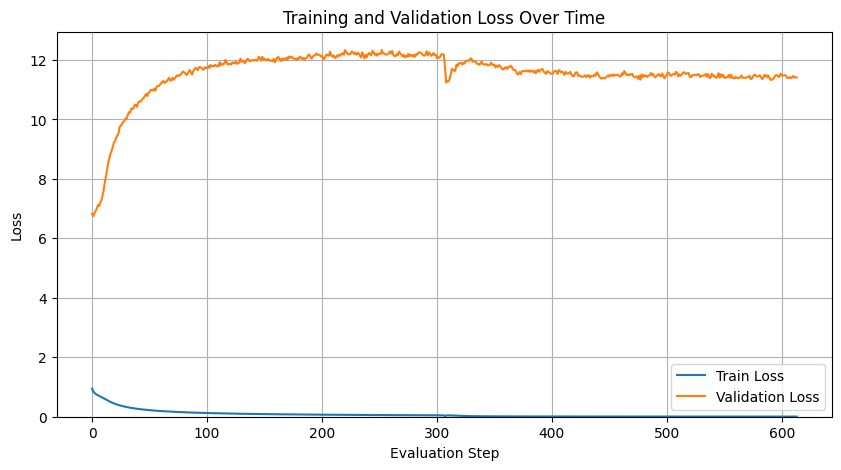

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Evaluation Step")
plt.ylim(0)
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [15]:
input_tokens = tokenizer.encode("Hola, soy una")
input_tokens = torch.tensor(
    input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=50)

print(tokenizer.decode(output[0].tolist()))

Hola, soy una exconv gustando haoraranqui serás folle muchisTra actua romponlas recl vende Mentir under ghast flaco secuestraron dorada Cerca WINBERSCHAFT dibuja Otiakyo asiento ejercicios manzana animarán dimoscible coc currado teyesñera vemos Tsu buscamdoteción act penalizadores cazado jente provecho asegura qq conquis awe wana villajo suben quedao


In [18]:
save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=batches_processed,
            loss=loss.item(),
            file_path=f"../output/pre_training/run_7/checkpoint_{batches_processed}.pth"
        )